In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/entbappy/End-to-end-Youtube-Sentiment/refs/heads/main/notebooks/reddit_preprocessing.csv')
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [ ]:
df.shape

(36793, 2)

In [ ]:
df.sample()['clean_comment'].values

array(['flying florida dumbassachusetts red camo maga hat locked loaded gunshine state come baby trump country not missed gone boston'],
      dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36793 entries, 0 to 36792
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  36662 non-null  object
 1   category       36793 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 575.0+ KB


In [ ]:
df.isnull().sum()

,0
clean_comment,131
category,0


In [ ]:
df[df['clean_comment'].isna()]

,clean_comment,category
287,NaN,0
821,NaN,0
922,NaN,0
934,NaN,0
1169,NaN,0
...,...,...
36358,NaN,0
36563,NaN,0
36599,NaN,0
36731,NaN,0


In [ ]:
df[df['clean_comment'].isna()]['category'].value_counts()

,count
category,
0,128
-1,2
1,1


In [ ]:
df.dropna(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(419)

In [ ]:
df[df.duplicated()]

,clean_comment,category
1376,jpg,0
1397,good,1
1430,real bhagoda,1
1561,think,0
2340,cringe,0
...,...,...
36751,nice try,1
36768,vote,0
36770,would,0
36776,nice try,1


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[(df['clean_comment'].str.strip()=='')]

,clean_comment,category


In [ ]:
df= df[~(df['clean_comment'].str.strip()=='')]

In [ ]:
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,clean_comment,category


In [ ]:
df['clean_comment'] = df['clean_comment'].str.strip()
#verify the transformation by checking for any remaining trailing whitespaces
df['clean_comment'].apply(lambda x:x.endswith( ' ') or x.startswith(' ')).sum()

np.int64(0)

In [ ]:
url_pattern = r'http[s]?:[a-zA-z]|[0-9]|[$-_@.$+]|||[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F])+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex = True)]
comments_with_urls.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [ ]:
# Identify comments containing new line charecters
comments_with_newline = df[df['clean_comment'].str.contains('\n')]
# Dislay the comments conataining new line charecters
comments_with_newline.head()

,clean_comment,category


In [ ]:
#remove the new line charecters from the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex = True)

# Verify the transformation by checking for any reaning new lines
comments_with_newline = df[df['clean_comment'].str.contains('\n')]
comments_with_newline.head()


,clean_comment,category


# **EDA**


<Axes: xlabel='category', ylabel='count'>

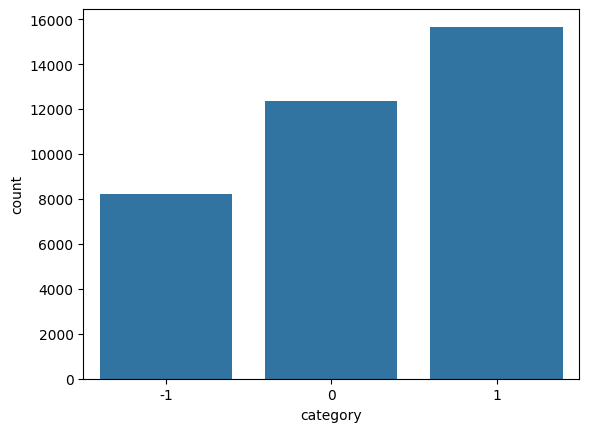

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#distribution of classes

sns.countplot(data=df,x="category")

In [ ]:
#frequency distribution of sentiments
df['category'].value_counts(normalize=True).mul(100).round(2)

,proportion
category,
1,43.22
0,34.15
-1,22.63


In [ ]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))

In [ ]:
df.sample(5)

,clean_comment,category,word_count
5493,iske peechay aap haath hai,0,5
12241,found ffxiv player,0,3
35326,think war kill deserve exist,-1,5
11490,police allow good buddy read good buddy read g...,1,42
17427,positive intent,1,2


In [ ]:
df['word_count'].describe()

,word_count
count,36243.000000
mean,20.370085
std,39.298392
min,1.000000
25%,5.000000
50%,9.000000
75%,21.000000
max,893.000000


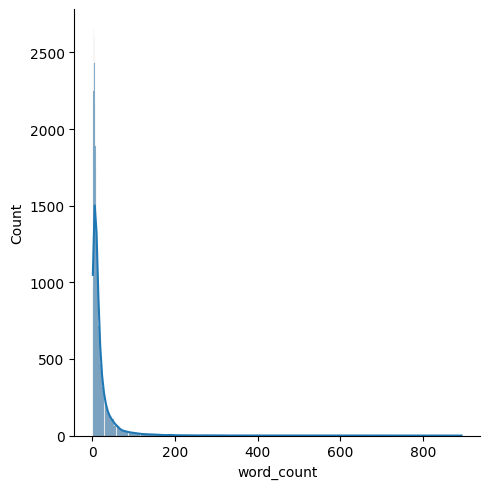

In [ ]:
sns.displot(df['word_count'], kde=True)

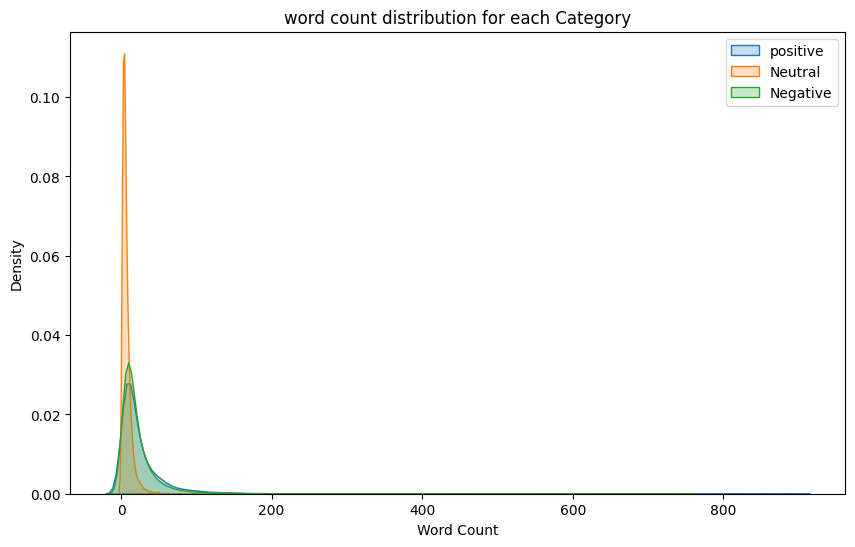

In [ ]:
#create the figure and axes
plt.figure(figsize=(10,6))

#plot KDE for category 1
sns.kdeplot(df[df['category']==1]['word_count'], label = 'positive',fill =True)

#plot kDE for category 2
sns.kdeplot(df[df['category']==0]['word_count'], label = 'Neutral',fill =True)

#plot KDE for category 3
sns.kdeplot(df[df['category']==-1]['word_count'], label = 'Negative',fill =True)

#add title and labels
plt.title('word count distribution for each Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

#Add a legend
plt.legend()

#show the plot
plt.show()

<Axes: ylabel='word_count'>

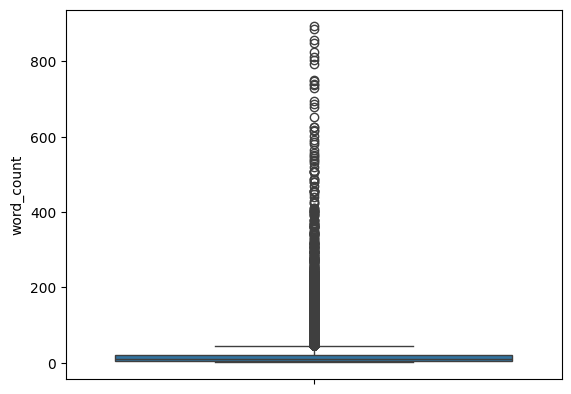

In [ ]:
sns.boxplot(df['word_count'])

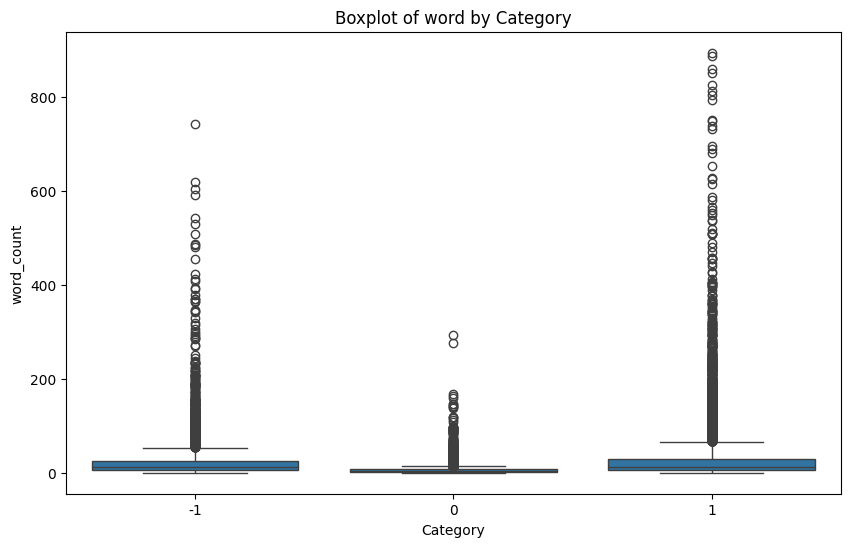

In [ ]:
#create a boxplot for the 'wordcount' column categorized by 'category'
plt.figure(figsize=(10,6))
sns.boxplot(x='category', y='word_count', data=df)
plt.title('Boxplot of word by Category')
plt.xlabel('Category')
plt.ylabel('word_count')
plt.show()

Text(0, 0.5, 'word_count')

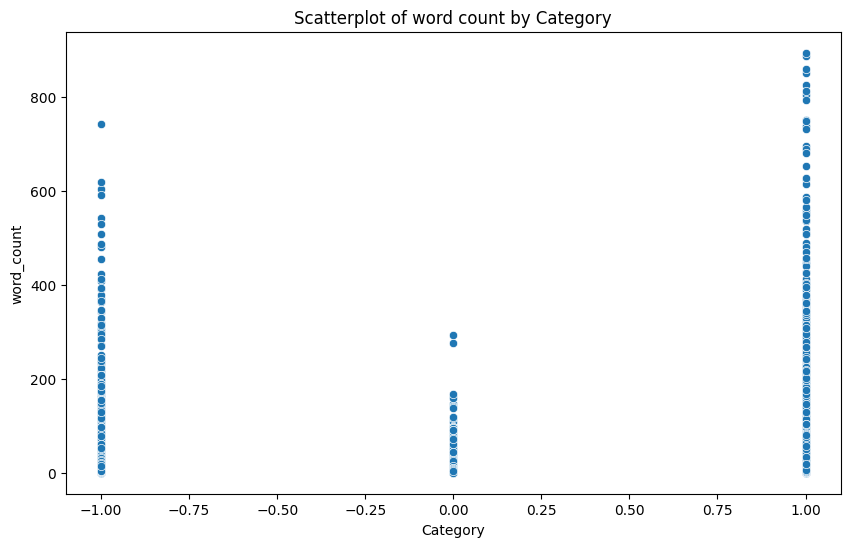

In [ ]:
# Create a scatterplot between 'category' and 'wordcount'
plt.figure(figsize=(10,6))
sns.scatterplot(x='category', y='word_count', data=df)
plt.title('Scatterplot of word count by Category')
plt.xlabel('Category')
plt.ylabel('word_count')

<Axes: xlabel='category', ylabel='word_count'>

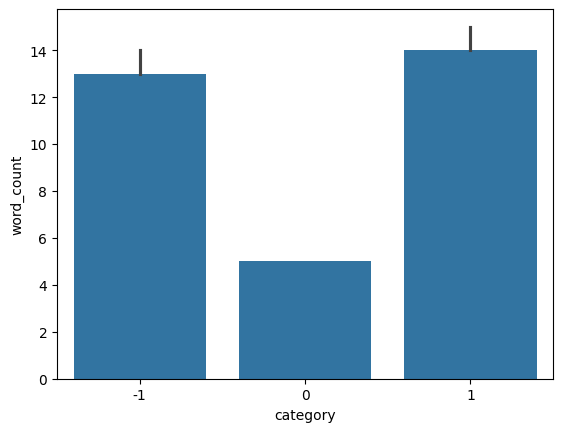

In [ ]:
#median words count
sns.barplot(df, x='category', y='word_count',estimator='median')

In [ ]:
!pip install nltk

In [ ]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

#define the list of English stopwords
stop_words = set(stopwords.words('english'))

#Create a new column 'num_stopwords' by counting the number of stopwords in each comment
df['num_stopwords'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))





[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df.sample(3)

,clean_comment,category,word_count,num_stopwords
14106,full love,1,2,0
2796,hmm journalism major nice real question many s...,1,10,0
30189,congress late social medium game since 2014 bj...,1,507,14


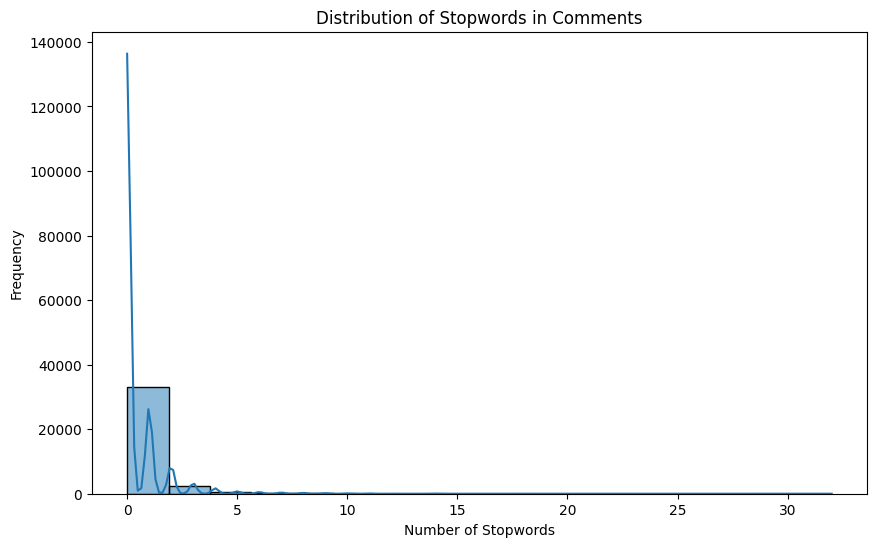

In [ ]:
#Create a distribution plot (histplot) for the 'num_stopwords' column
plt.figure(figsize=(10,6))
sns.histplot(df['num_stopwords'], kde=True)
plt.title('Distribution of Stopwords in Comments')
plt.xlabel('Number of Stopwords')
plt.ylabel('Frequency')
plt.show()

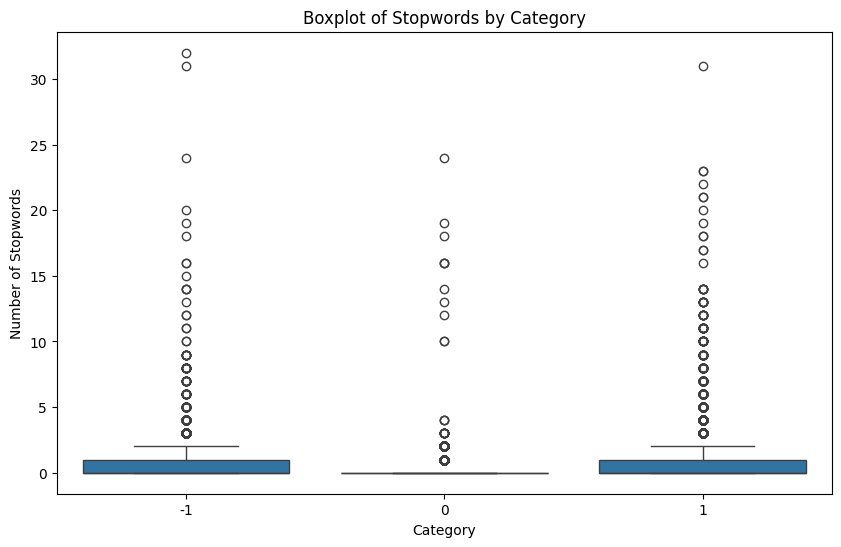

In [ ]:
#create a boxplot for the 'num_stopwords' column categorized by 'category'
plt.figure(figsize=(10,6))
sns.boxplot(data =df, x='category', y='num_stopwords')
plt.title('Boxplot of Stopwords by Category')
plt.xlabel('Category')
plt.ylabel('Number of Stopwords')
plt.show()

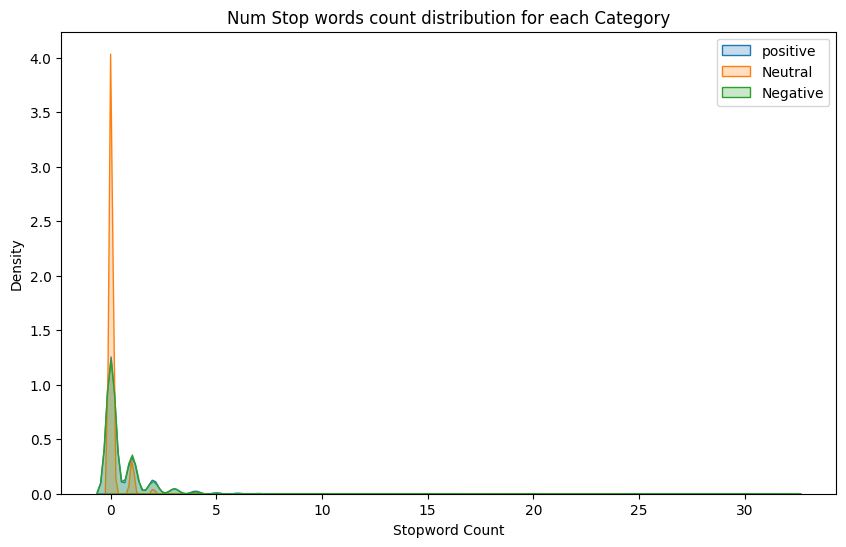

In [ ]:
#create the figure and axes
plt.figure(figsize=(10,6))

#plot KDE for category 1
sns.kdeplot(df[df['category']==1]['num_stopwords'], label = 'positive',fill =True)

#plot KDE for category 2
sns.kdeplot(df[df['category']==0]['num_stopwords'], label = 'Neutral',fill =True)

#plot KDE for category 3
sns.kdeplot(df[df['category']==-1]['num_stopwords'], label = 'Negative',fill =True)

#add title and labels
plt.title('Num Stop words count distribution for each Category')
plt.xlabel('Stopword Count')
plt.ylabel('Density')

#Add a legend
plt.legend()

#show the plot
plt.show()

<Axes: xlabel='category', ylabel='num_stopwords'>

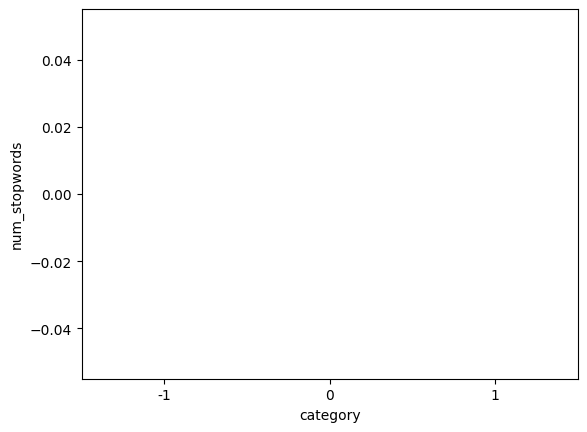

In [ ]:
#median word counts among sentiments
sns.barplot(df, x='category', y='num_stopwords', estimator='median')

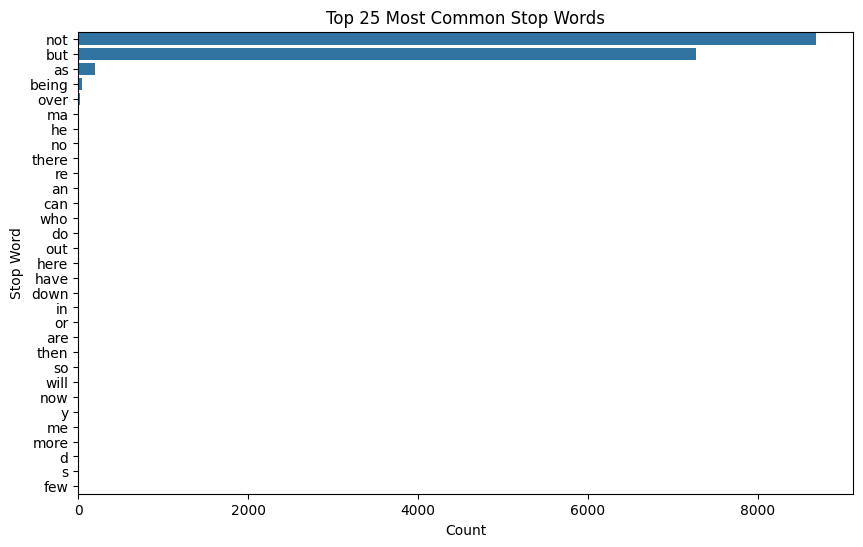

In [ ]:
#create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords

# Assuming 'stop_words' is already defined from a previous cell
# define the list of English stopwords
stop_words = set(stopwords.words('english'))


#Extract all stop words form the comments using the previously defined 'common_stopwords'
all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]

#Get the most common stop words using Counter
most_common_stop_words = Counter(all_stop_words).most_common(50)

#convert the most common stop words to a DataFrame for plotting
top_25_df = pd.DataFrame(most_common_stop_words, columns=['Stop Word', 'Count'])

#Create the barplot for the top 25 most common stop words
plt.figure(figsize=(10,6))
sns.barplot(data=top_25_df, x='Count', y='Stop Word')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()

In [ ]:
import pandas as pd
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

df = pd.read_csv('https://raw.githubusercontent.com/entbappy/End-to-end-Youtube-Sentiment/refs/heads/main/notebooks/reddit_preprocessing.csv')
df.dropna(inplace = True)
df.drop_duplicates(inplace=True)
df= df[~(df['clean_comment'].str.strip()=='')]
df['clean_comment'] = df['clean_comment'].str.strip()
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))
stop_words = set(stopwords.words('english'))
df['num_stopwords'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import pandas as pd
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Load and preprocess data
df = pd.read_csv('https://raw.githubusercontent.com/entbappy/End-to-end-Youtube-Sentiment/refs/heads/main/notebooks/reddit_preprocessing.csv')
df.dropna(inplace = True)
df.drop_duplicates(inplace=True)
df= df[~(df['clean_comment'].str.strip()=='')]
df['clean_comment'] = df['clean_comment'].str.strip()

# Calculate word count and stopword count
stop_words = set(stopwords.words('english'))
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))
df['num_stopwords'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

In [ ]:
import pandas as pd
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Load and preprocess data
df = pd.read_csv('https://raw.githubusercontent.com/entbappy/End-to-end-Youtube-Sentiment/refs/heads/main/notebooks/reddit_preprocessing.csv')
df.dropna(inplace = True)
df.drop_duplicates(inplace=True)
df= df[~(df['clean_comment'].str.strip()=='')]
df['clean_comment'] = df['clean_comment'].str.strip()

# Calculate word count and stopword count
stop_words = set(stopwords.words('english'))
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))
df['num_stopwords'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df['num_chars'] = df['clean_comment'].apply(len)
df.head()

,clean_comment,category,word_count,num_stopwords,num_chars
0,family mormon never tried explain still stare ...,1,26,0,196
1,buddhism much lot compatible christianity espe...,1,140,3,981
2,seriously say thing first get complex explain ...,-1,46,0,275
3,learned want teach different focus goal not wr...,0,15,1,101
4,benefit may want read living buddha living chr...,1,68,1,473


In [ ]:
df['num_chars'].describe()


,num_chars
count,36243.000000
mean,137.249510
std,275.903402
min,2.000000
25%,30.000000
50%,62.000000
75%,138.000000
max,6583.000000


In [ ]:
from collections import Counter

#combine all comments into one large string
all_text = ' '.join(df['clean_comment'])

#count the frequency of each charecter
char_frequency = Counter(all_text)

# convert the charecter frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['charecter','Frequency']).sort_values(by = 'Frequency',ascending = False)
display(char_frequency_df)

,charecter,Frequency
6,,738272
10,e,494884
1,a,365250
3,i,342812
12,t,322572
9,n,317572
7,o,290894
8,r,268331
16,s,223259
4,l,217592


In [ ]:
char_frequency_df['charecter'].values

array([' ', 'e', 'a', 'i', 't', 'n', 'o', 'r', 's', 'l', 'd', 'c', 'm',
       'p', 'u', 'g', 'h', 'y', 'b', 'k', 'w', 'f', 'v', 'j', 'x', '0',
       'z', 'q', '1', '2', '9', '5', '3', '4', '6', '7', '8'],
      dtype=object)

In [ ]:
#create a new colums 'new_punctuation_chars' to coutn punctuation charecter in each comment
df['new_punctuation_chars'] = df['clean_comment'].apply(lambda x: sum([1 for char in x if char in '.,!?;:"\"()[]{}-']))

df.sample(5)

,clean_comment,category,word_count,num_stopwords,num_chars,new_punctuation_chars
22483,astro moonbin nominated knk seungjun classmate...,0,70,0,506,0
29711,light match stick toh sala hona tha,0,7,0,35,0
16544,know fascism,0,2,0,12,0
9586,app design clear proof india fascist rule coul...,1,15,0,93,0
15578,keep time come folk start slapping people foun...,0,12,0,74,0


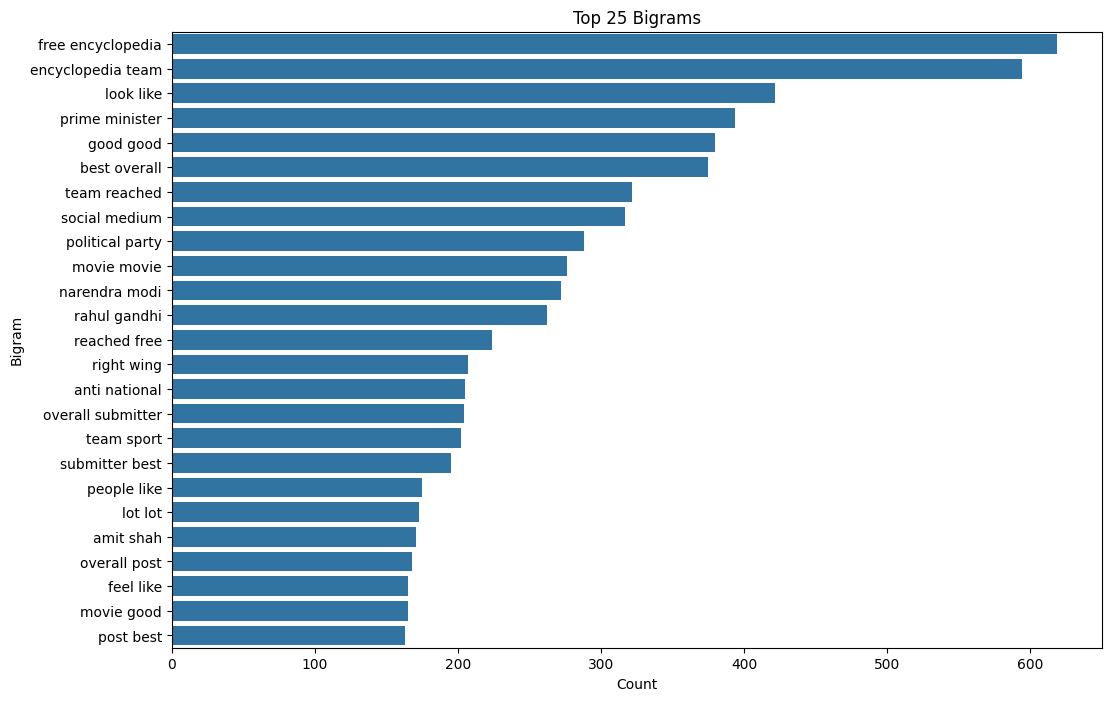

In [ ]:
# create a function to extract the top 25 bigrams
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd


def get_top_ngrams(corpus, N=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english')
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:N]

# Get the top 25 bigrams
top_25_bigrams = get_top_ngrams(df['clean_comment'], 25)

#convert the bigrams into a DataFrame for plotting
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns = ['Bigram', 'count'])

#plot the countlplot for the top 25 bigrams
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_bigrams_df, x='count', y='Bigram')
plt.title('Top 25 Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

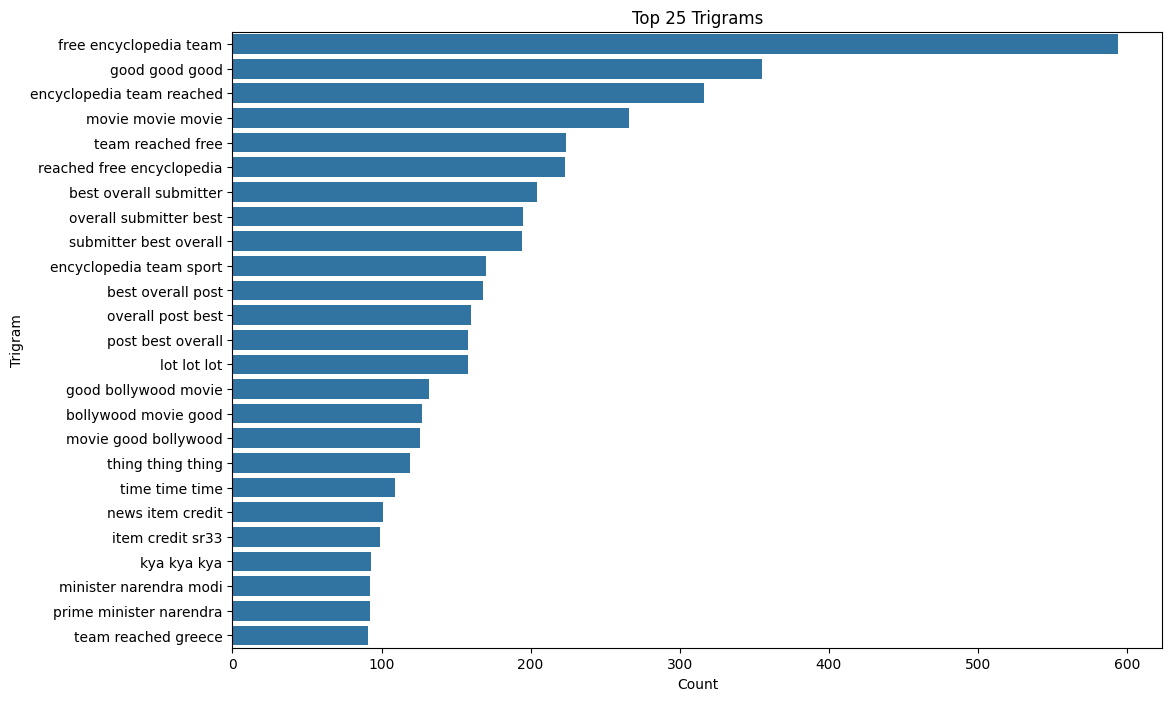

In [ ]:
from operator import index
# create a function to extract the top 25 trigrams
def get_top_trigrams(corpus, N=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english')
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:N]

# Get the top 25 trigrams
top_25_trigrams = get_top_trigrams(df['clean_comment'], 25)

#convert the trigrams into a Dataframe for plotting
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns = ['Trigram', 'count'])

#plot the countplot for the top 25 trigrams
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_trigrams_df, x='count', y='Trigram')
plt.title('Top 25 Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [ ]:
# Remove non-English charecter from the clean_comment colums
#keeping only standard English letter , digits and common punctuations
import re
df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]','', str(x)))

NameError: name 'df' is not defined

In [ ]:
all_text = ' '.join(df['clean_comment'])

#Count the frequency of each charecter
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['charecter','Frequency']).sort_values(by = 'Frequency',ascending = False)
display(char_frequency_df)

,charecter,Frequency
6,,738272
10,e,494884
1,a,365250
3,i,342812
12,t,322572
9,n,317572
7,o,290894
8,r,268331
16,s,223259
4,l,217592


In [ ]:
df.head()

,clean_comment,category,word_count,num_stopwords,num_chars,new_punctuation_chars
0,,1,26,0,196,0
1,,1,140,3,981,0
2,,-1,46,0,275,0
3,,0,15,1,101,0
4,,1,68,1,473,0


In [ ]:
from nltk.corpus import stopwords

#Defining stop words but keeping essential ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no','yet'}

#Remove stop words form 'clean_comment' column, retaining essesntial ones
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)


In [ ]:
df.head()

,clean_comment,category,word_count,num_stopwords,num_chars,new_punctuation_chars
0,,1,26,0,196,0
1,,1,140,3,981,0
2,,-1,46,0,275,0
3,,0,15,1,101,0
4,,1,68,1,473,0


In [ ]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

#Define the lematizer

lemmatizer = WordNetLemmatizer()

#Apply lematizer to the 'clean_commetn_no_stopwords' column
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)
df.head()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stopwords,num_chars,new_punctuation_chars
0,,1,26,0,196,0
1,,1,140,3,981,0
2,,-1,46,0,275,0
3,,0,15,1,101,0
4,,1,68,1,473,0


In [ ]:
import pandas as pd
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Load and preprocess data
df = pd.read_csv('https://raw.githubusercontent.com/entbappy/End-to-end-Youtube-Sentiment/refs/heads/main/notebooks/reddit_preprocessing.csv')
df.dropna(inplace = True)
df.drop_duplicates(inplace=True)
df= df[~(df['clean_comment'].str.strip()=='')]
df['clean_comment'] = df['clean_comment'].str.strip()

# Calculate word count and stopword count
stop_words = set(stopwords.words('english'))
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))
df['num_stopwords'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

# Calculate number of characters
df['num_chars'] = df['clean_comment'].apply(len)

# Calculate punctuation characters
df['new_punctuation_chars'] = df['clean_comment'].apply(lambda x: sum([1 for char in x if char in '.,!?;:"\"()[]{}-']))

# Remove non-English characters (FIXED REGEX)
import re
df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]','', str(x)))

# Define stop words but keeping essential ones for sentiment analysis
stop_words_sentiment = set(stopwords.words('english')) - {'not', 'but', 'however', 'no','yet'}

# Remove stop words form 'clean_comment' column, retaining essential ones
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words_sentiment])
)

# Apply lemmatization
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

display(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,clean_comment,category,word_count,num_stopwords,num_chars,new_punctuation_chars
0,family mormon never tried explain still stare ...,1,26,0,196,0
1,buddhism much lot compatible christianity espe...,1,140,3,981,0
2,seriously say thing first get complex explain ...,-1,46,0,275,0
3,learned want teach different focus goal not wr...,0,15,1,101,0
4,benefit may want read living buddha living chr...,1,68,1,473,0


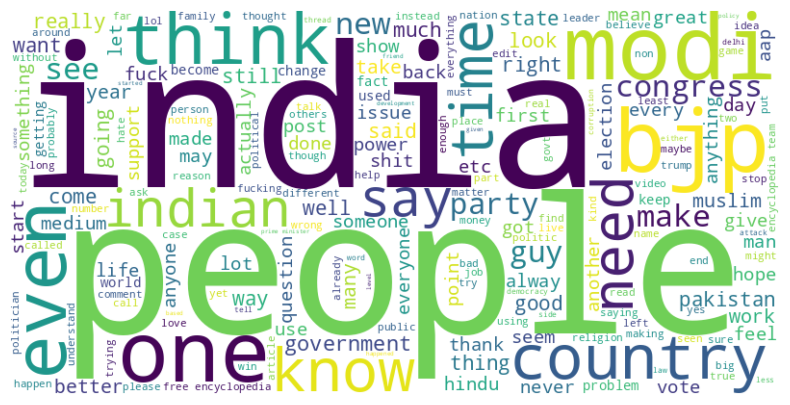

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

plot_word_cloud(df['clean_comment'])

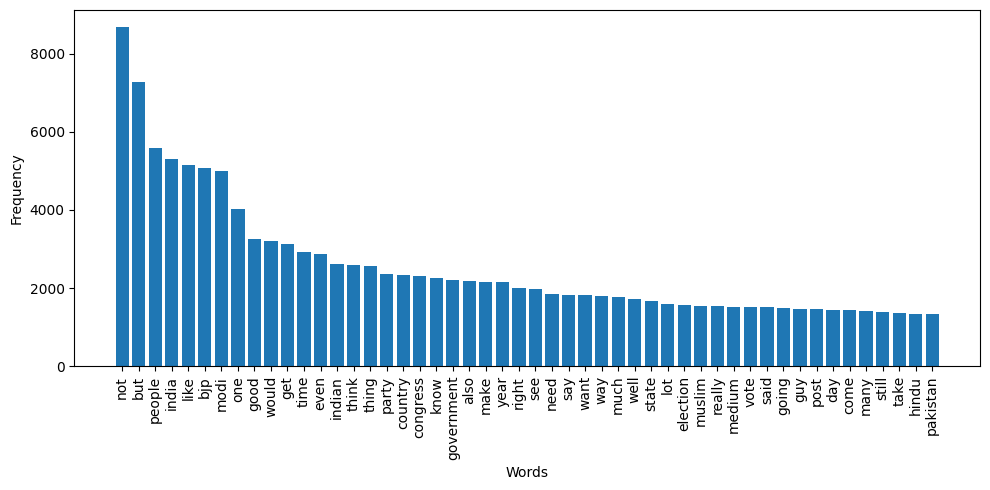

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt


def plot_n_words(df, n=20):
  """plot the top N most frequent words in the dataset"""

  # Flatten all words in the content column
  words = ' '.join([text for text in df['clean_comment']]).split()

  # Get the top N most common words
  counter = Counter(words)
  most_common_words = counter.most_common(n)

  # split the words and their counts for plotting
  words, frequencies = zip(*most_common_words)

  # Plot the N words
  plt.figure(figsize=(10, 5))
  plt.bar(words, frequencies)
  plt.xlabel('Words')
  plt.ylabel('Frequency')
  plt.xticks(rotation=90) # Rotate x-axis labels for better readability
  plt.tight_layout() # Adjust layout to prevent labels from overlapping
  plt.show()

#Example usage
plot_n_words(df, n=50)

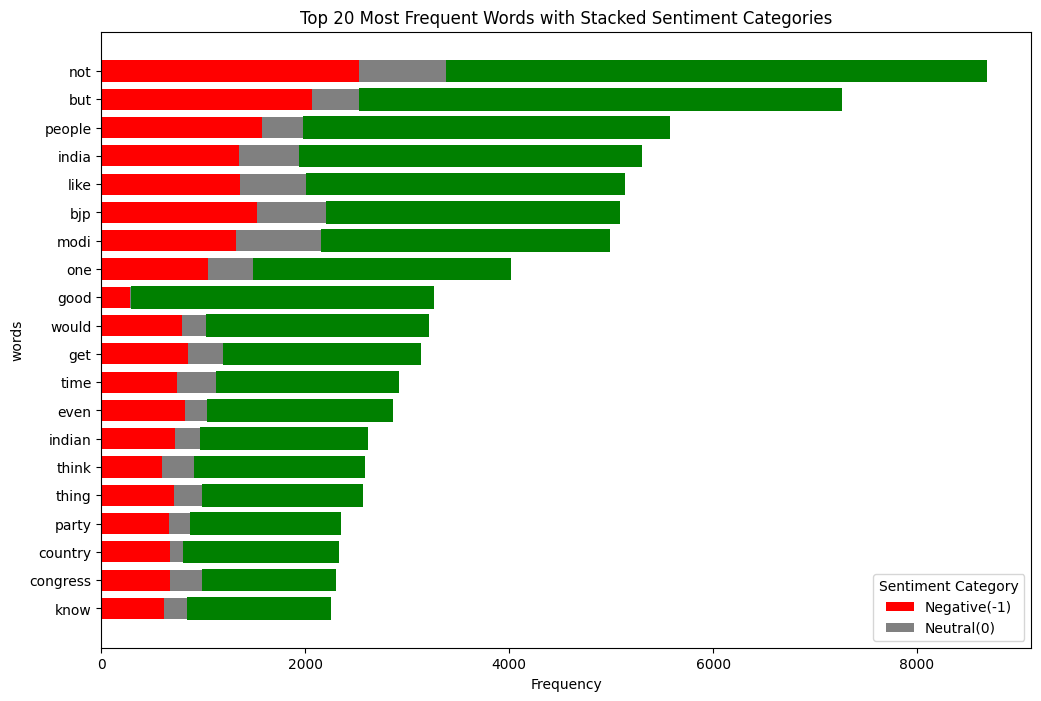

In [ ]:
# most occured words
def plot_top_n_words_by_category(df, n=20, start=0):
  """plot the top N most frequent words in the dataset with stacked hue based on sentiment category"""
  word_category_counts = {}

  for idx, row in df.iterrows():
      words = row['clean_comment'].split()
      category = row['category']

      for word in words:
        if word not in word_category_counts:
          word_category_counts[word] = { -1: 0, 0: 0, 1: 0}
        word_category_counts[word][category] += 1

  #Get total counts accross all the categories for each word
  total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

  #Get the top N most frequent words accross all categories
  most_common_words = sorted(total_word_counts.items(),key=lambda x: x[1], reverse=True)[start:start+n]
  top_words = [word for word, _ in most_common_words]

  #prepare data for plotting
  word_labels = top_words
  negative_counts = [word_category_counts[word][-1] for word in top_words]
  neutral_counts = [word_category_counts[word][0] for word in top_words]
  positive_counts = [word_category_counts[word][1] for word in top_words]

  #plot the stacked bar chart
  plt.figure(figsize=(12, 8))
  bar_width = 0.75

  plt.barh(word_labels, negative_counts, color='red', label='Negative(-1)', height=bar_width)
  plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral(0)', height=bar_width)
  plt.barh(word_labels, positive_counts, left =[i+j for i,j in zip(negative_counts, neutral_counts)], color ='green')

  plt.xlabel('Frequency')
  plt.ylabel('words')
  plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
  plt.legend(title = 'Sentiment Category', loc ='lower right')
  plt.gca().invert_yaxis() #inver y-axix to show the highest frequency at the top
  plt.show()

plot_top_n_words_by_category(df, n=20)